Mount Google Drive and check GPU

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import tensorflow as tf
device = tf.test.gpu_device_name()
print('Using device:', 'GPU' if device else 'CPU')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using device: GPU


In [2]:

device_name = tf.test.gpu_device_name()
if device_name:
    print('Using device:', device_name)
else:
    print('No GPU found. Using CPU instead.')

Using device: /device:GPU:0


In [3]:
!pip show tensorflow
print("TensorFlow version:", tf.__version__)

Name: tensorflow
Version: 2.17.1
Summary: TensorFlow is an open source machine learning framework for everyone.
Home-page: https://www.tensorflow.org/
Author: Google Inc.
Author-email: packages@tensorflow.org
License: Apache 2.0
Location: /usr/local/lib/python3.10/dist-packages
Requires: absl-py, astunparse, flatbuffers, gast, google-pasta, grpcio, h5py, keras, libclang, ml-dtypes, numpy, opt-einsum, packaging, protobuf, requests, setuptools, six, tensorboard, tensorflow-io-gcs-filesystem, termcolor, typing-extensions, wrapt
Required-by: dopamine_rl, tf_keras
TensorFlow version: 2.17.1


In [4]:
!pip install keras

Import required libraries

In [5]:
import os
import cv2
import random
import itertools
import tensorflow as tf
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.utils import to_categorical, plot_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator


from keras import layers, regularizers, optimizers, callbacks
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

Set image size and define data loading function

In [6]:
img_size=96
def load_data(path, train=True):
    print("Loading data from: ", path)
    data = []
    for img in os.listdir(path):
        imgname, ext = os.path.splitext(img)
        ID, etc = imgname.split('__')
        ID = int(ID) - 1 # to_categorical encodes starting from 0
        if train:
            _, lr, finger, _, _ = etc.split('_')
        else:
            _, lr, finger, _  = etc.split('_')
        if lr=='Left':
            base = 0 # left hand corresponding to 0-4
        else: base  = 5 # right hand corresponding to 5-9
        if finger=="little":
            fingerNum = base + 0
        elif finger=='ring':
            fingerNum = base + 1
        elif finger=='middle':
            fingerNum = base + 2
        elif finger=='index':
            fingerNum = base + 3
        else: fingerNum = base + 4
        img_array = cv2.imread(os.path.join(path, img), cv2.IMREAD_GRAYSCALE)
        img_resize = cv2.resize(img_array, (img_size, img_size))
        # Convert image to numpy array and ensure consistent type
        img_resize = np.array(img_resize, dtype=np.float32)
        data.append([np.array(ID, dtype=np.int32),
                    np.array(fingerNum, dtype=np.int32),
                    img_resize])

    # Convert to numpy array with explicit dtype
    return np.array(data, dtype=object)

Define paths and load data

In [7]:
base_path = "/content/drive/MyDrive/dataset"
Altered_path = os.path.join(base_path, "Altered/Altered-")
Real_path = os.path.join(base_path, "Real")

# Load data with the fixed function
Easy_data = load_data(Altered_path+'Easy', train=True)
Medium_data = load_data(Altered_path+'Medium', train=True)
Hard_data = load_data(Altered_path+'Hard', train=True)
Real_data = load_data(Real_path, train=False)

Loading data from:  /content/drive/MyDrive/dataset/Altered/Altered-Easy
Loading data from:  /content/drive/MyDrive/dataset/Altered/Altered-Medium
Loading data from:  /content/drive/MyDrive/dataset/Altered/Altered-Hard
Loading data from:  /content/drive/MyDrive/dataset/Real


concatenate

In [8]:
Altered_data = np.concatenate([Easy_data, Medium_data, Hard_data], axis=0)
del Easy_data, Medium_data, Hard_data # Free some memory

Create datasets

In [9]:
X_Altered, y_SubjectID_Altered, y_fingerNum_Altered = [], [], []

for SubjectID, fingerNum, feature in Altered_data:
    X_Altered.append(feature)
    y_SubjectID_Altered.append(SubjectID)
    y_fingerNum_Altered.append(fingerNum)

Transfer data to GPU if available

In [10]:
with tf.device('/GPU:0' if device else '/CPU:0'):
    X_Altered = np.array(X_Altered).reshape(-1, img_size, img_size, 1)
    X_Altered = X_Altered / 255.0
    y_SubjectID_Altered = to_categorical(y_SubjectID_Altered, num_classes=600)
    y_fingerNum_Altered = to_categorical(y_fingerNum_Altered, num_classes=10)

Split datasets

In [11]:
X_SubjectID_train, X_SubjectID_val, y_SubjectID_train, y_SubjectID_val = train_test_split(
    X_Altered, y_SubjectID_Altered, test_size=0.2, random_state=2)
X_fingerNum_train, X_fingerNum_val, y_fingerNum_train, y_fingerNum_val = train_test_split(
    X_Altered, y_fingerNum_Altered, test_size=0.2, random_state=2)


Prepare test data

In [12]:
X_test, y_SubjectID_test, y_fingerNum_test = [], [], []

for SubjectID, fingerNum, feature in Real_data:
    X_test.append(feature)
    y_SubjectID_test.append(SubjectID)
    y_fingerNum_test.append(fingerNum)

with tf.device('/GPU:0' if device else '/CPU:0'):
    X_test = np.array(X_test).reshape(-1, img_size, img_size, 1)
    X_test = X_test / 255.0
    y_SubjectID_test = to_categorical(y_SubjectID_test, num_classes=600)
    y_fingerNum_test = to_categorical(y_fingerNum_test, num_classes=10)

Output shapes of datasets

In [13]:
print("Shapes:                  Feature shape    label shape")
print("----------------------------------------------------")
print("full SubjectID data:  ", X_Altered.shape, y_SubjectID_Altered.shape)
print("SubjectID_Train:      ", X_SubjectID_train.shape, y_SubjectID_train.shape)
print("SubjectID_Validation: ", X_SubjectID_val.shape, y_SubjectID_val.shape)
print("SubjectID_Test:       ", X_test.shape, y_SubjectID_test.shape)
print("----------------------------------------------------")
print("full fingerNum data:  ", X_Altered.shape, y_fingerNum_Altered.shape)
print("fingerNum_Train:      ", X_fingerNum_train.shape, y_fingerNum_train.shape)
print("fingerNum_Validation: ", X_fingerNum_val.shape, y_fingerNum_val.shape)
print("fingerNum_Test:       ", X_test.shape, y_fingerNum_test.shape)

del Altered_data, Real_data, y_SubjectID_Altered # Free some memory

Shapes:                  Feature shape    label shape
----------------------------------------------------
full SubjectID data:   (49270, 96, 96, 1) (49270, 600)
SubjectID_Train:       (39416, 96, 96, 1) (39416, 600)
SubjectID_Validation:  (9854, 96, 96, 1) (9854, 600)
SubjectID_Test:        (6000, 96, 96, 1) (6000, 600)
----------------------------------------------------
full fingerNum data:   (49270, 96, 96, 1) (49270, 10)
fingerNum_Train:       (39416, 96, 96, 1) (39416, 10)
fingerNum_Validation:  (9854, 96, 96, 1) (9854, 10)
fingerNum_Test:        (6000, 96, 96, 1) (6000, 10)


Create models with GPU support

/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "SubjectID_Mod"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 92, 92, 32)          │             832 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 92, 92, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 46, 46, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 42, 42, 64)          │          51,264 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 42, 42, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 21, 21, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 19, 19, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 19, 19, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 9, 9, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 9, 9, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 10368)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │       2,654,464 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 600)                 │         154,200 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,935,512 (11.20 MB)

 Trainable params: 2,935,064 (11.20 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)                    │ (None, 92, 92, 32)          │             832 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 92, 92, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 46, 46, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 42, 42, 64)          │          51,264 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 42, 42, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 21, 21, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 19, 19, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 19, 19, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 9, 9, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 9, 9, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 10368)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 256)                 │       2,654,464 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 10)                  │           2,570 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,783,882 (10.62 MB)

 Trainable params: 2,783,434 (10.62 MB)

 Non-trainable params: 448 (1.75 KB)

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
graphviz is already the newest version (2.42.2-6ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 49 not upgraded.


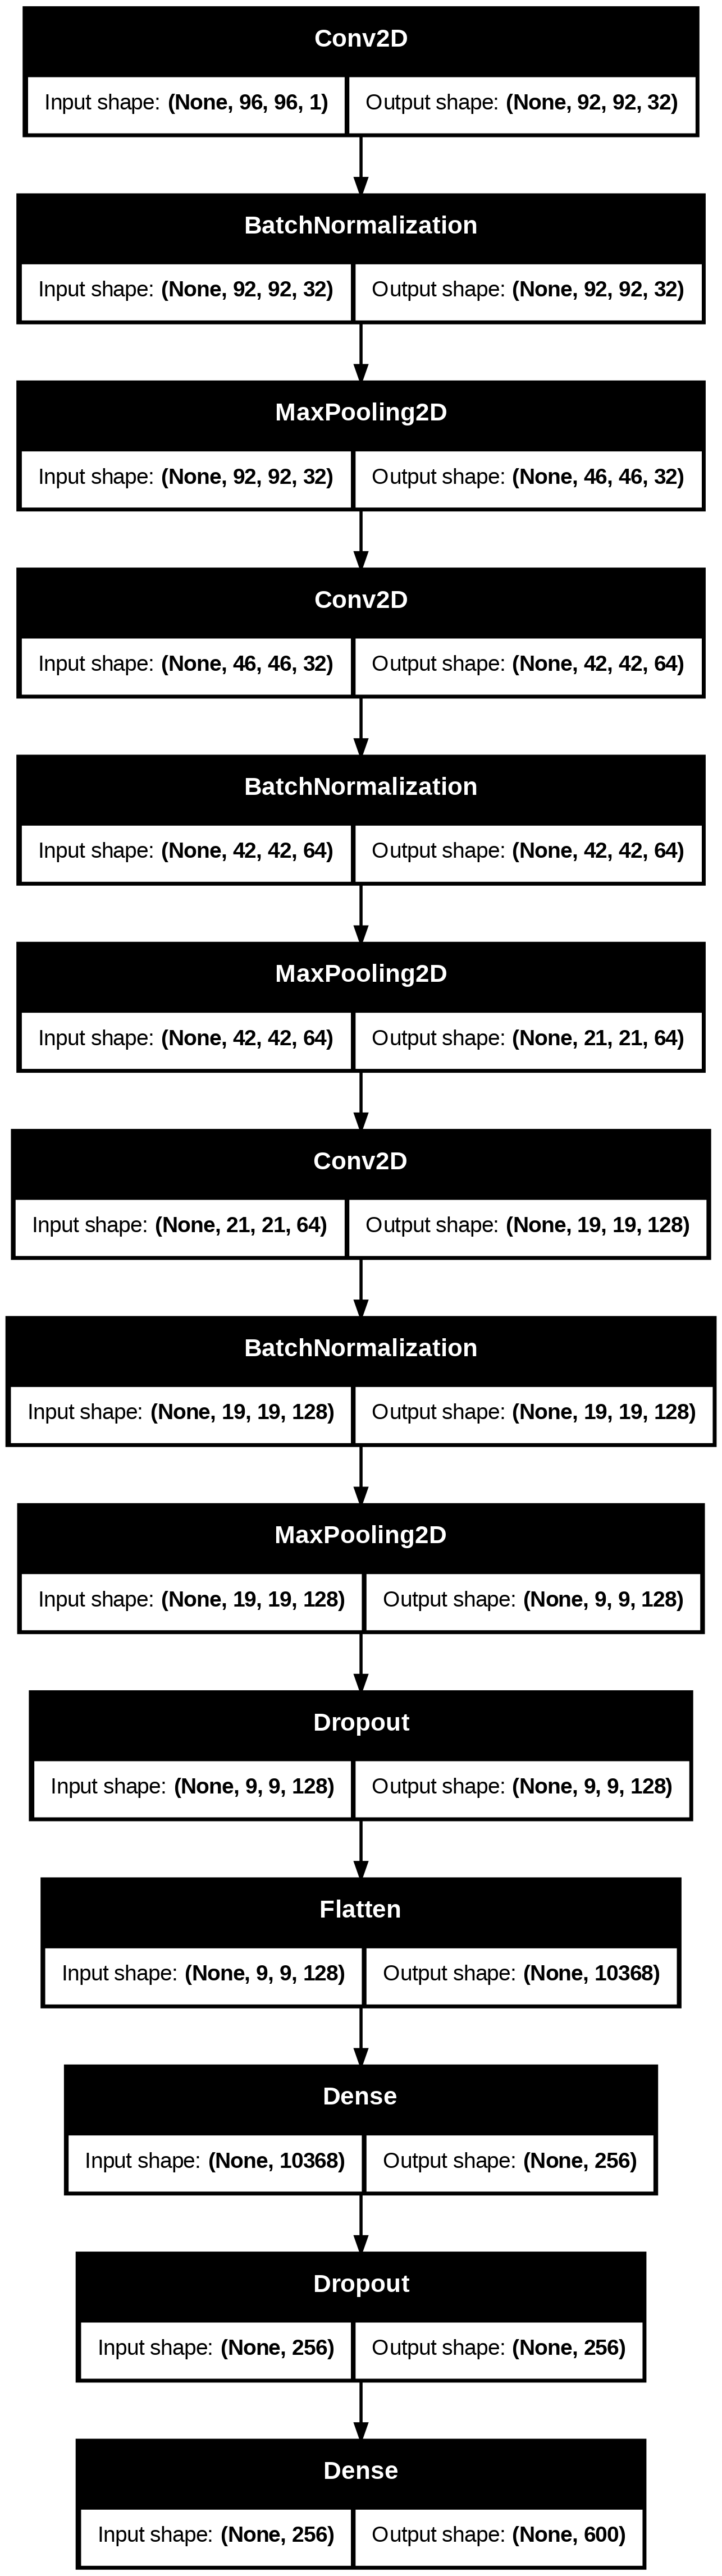

In [14]:
with tf.device('/GPU:0' if device else '/CPU:0'):
    nets = 2
    model = [0] * nets
    final_Dense_units = [600, 10]
    model_name = ['SubjectID_Mod', 'FingerNum_Mod']
    for i in range(nets):
        model[i] = Sequential(name=model_name[i])

        model[i].add(layers.Conv2D(32, (5, 5), activation='relu', kernel_regularizer=regularizers.l2(0.001), input_shape = (96, 96, 1)))
        model[i].add(layers.BatchNormalization())
        model[i].add(layers.MaxPool2D((2, 2)))
        model[i].add(layers.Conv2D(64,(5, 5), activation='relu', kernel_regularizer=regularizers.l2(0.001)))
        model[i].add(layers.BatchNormalization())
        model[i].add(layers.MaxPool2D((2, 2)))
        model[i].add(layers.Conv2D(128,(3, 3), activation='relu', kernel_regularizer=regularizers.l2(0.001)))
        model[i].add(layers.BatchNormalization())
        model[i].add(layers.MaxPool2D((2, 2)))
        model[i].add(layers.Dropout(0.3))
        model[i].add(layers.Flatten())
        model[i].add(layers.Dense(256, activation='relu'))
        model[i].add(layers.Dropout(0.4))
        model[i].add(layers.Dense(final_Dense_units[i], activation='softmax'))

        model[i].compile(optimizer=optimizers.Adam(learning_rate=0.0001),
                        loss="categorical_crossentropy",
                        metrics=["accuracy"])
        model[i].summary()

# Cell 10: Visualize models
!apt-get install graphviz
plot_model(model[0], show_shapes=True, to_file='/content/model0.png')

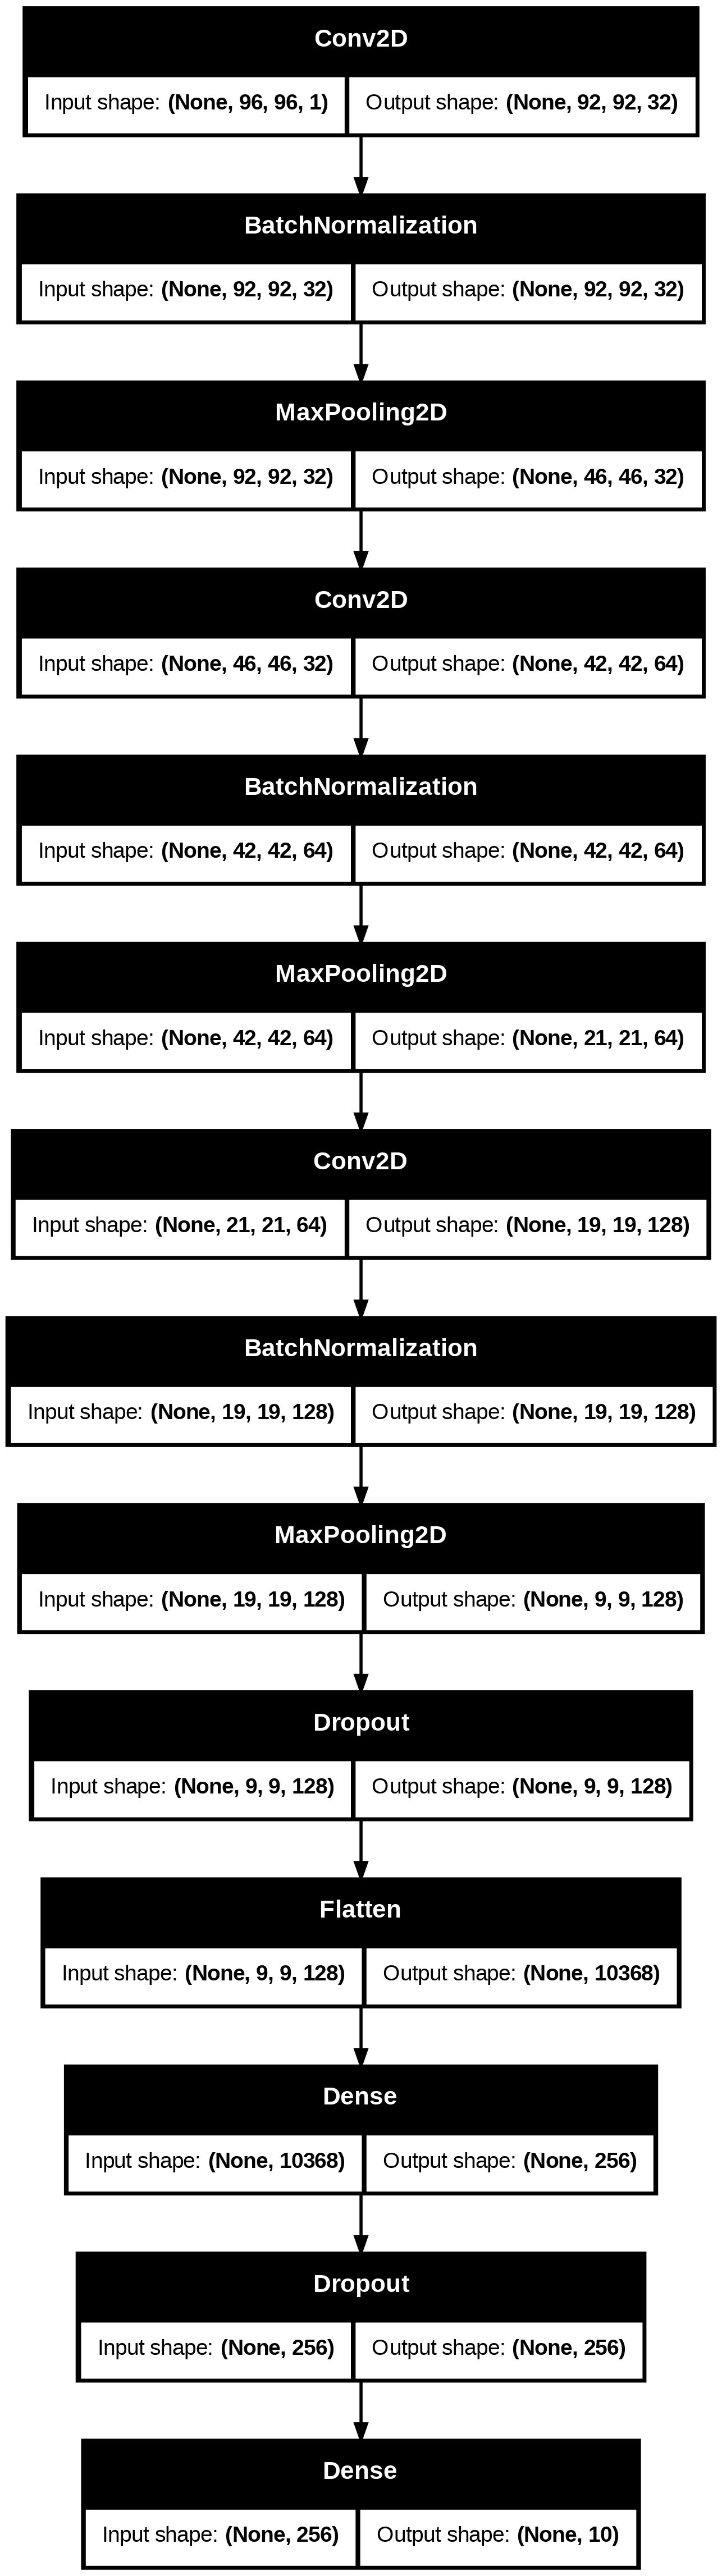

In [15]:
# Plot finger model grapy in layers
plot_model(model[1], show_shapes=True, to_file='/content/model1.png')

Create TensorBoard logs directory

In [16]:
log_dir = "/content/drive/MyDrive/fingerprint_logs"
if not os.path.exists(log_dir):
    os.makedirs(log_dir)

Prepare for training and manage memory

In [17]:
del X_fingerNum_train, X_fingerNum_val, y_fingerNum_train, y_fingerNum_val

Train models

In [18]:
history = [0] * nets
CallBack = [0] * nets
ReduceLR_minlr = [1e-9, 1e-7]
epochs = 20
batch_size = 64

for i in range(nets):
    CallBack[i] = [
        callbacks.EarlyStopping(monitor='val_accuracy', patience=10, mode='max', verbose=1),
        callbacks.ReduceLROnPlateau(factor=0.1, patience=1, min_lr=ReduceLR_minlr[i], verbose=1),
        callbacks.TensorBoard(log_dir=os.path.join(log_dir, model_name[i]))]

Train first model

In [19]:
history[0] = model[0].fit(
    X_SubjectID_train,
    y_SubjectID_train,
    batch_size=batch_size,
    epochs=epochs,
    validation_data=(X_SubjectID_val, y_SubjectID_val),
    verbose=1,
    callbacks=CallBack[0],

)

Epoch 1/20
616/616 ━━━━━━━━━━━━━━━━━━━━ 35s 38ms/step - accuracy: 0.0033 - loss: 6.6077 - val_accuracy: 0.0090 - val_loss: 6.4397 - learning_rate: 1.0000e-04
Epoch 2/20
616/616 ━━━━━━━━━━━━━━━━━━━━ 23s 24ms/step - accuracy: 0.0191 - loss: 6.1357 - val_accuracy: 0.0978 - val_loss: 5.2922 - learning_rate: 1.0000e-04
Epoch 3/20
616/616 ━━━━━━━━━━━━━━━━━━━━ 15s 24ms/step - accuracy: 0.0970 - loss: 5.0835 - val_accuracy: 0.3112 - val_loss: 3.8647 - learning_rate: 1.0000e-04
Epoch 4/20
616/616 ━━━━━━━━━━━━━━━━━━━━ 20s 24ms/step - accuracy: 0.3069 - loss: 3.4630 - val_accuracy: 0.7231 - val_loss: 2.0903 - learning_rate: 1.0000e-04
Epoch 5/20
616/616 ━━━━━━━━━━━━━━━━━━━━ 15s 24ms/step - accuracy: 0.5706 - loss: 2.0285 - val_accuracy: 0.8686 - val_loss: 1.0637 - learning_rate: 1.0000e-04
Epoch 6/20
616/616 ━━━━━━━━━━━━━━━━━━━━ 15s 24ms/step - accuracy: 0.7506 - loss: 1.1914 - val_accuracy: 0.9328 - val_loss: 0.6340 - learning_rate: 1.0000e-04
Epoch 7/20
616/616 ━━━━━━━━━━━━━━━━━━━━ 20s 24ms/ste

Memory management and second model training

In [20]:
del X_SubjectID_train, X_SubjectID_val, y_SubjectID_train, y_SubjectID_val
X_fingerNum_train, X_fingerNum_val, y_fingerNum_train, y_fingerNum_val = train_test_split(
    X_Altered, y_fingerNum_Altered, test_size=0.2, random_state=2)

del X_Altered, y_fingerNum_Altered

Train second model

In [21]:
history[1] = model[1].fit(
    X_fingerNum_train,
    y_fingerNum_train,
    batch_size=batch_size,
    epochs=epochs,
    validation_data=(X_fingerNum_val, y_fingerNum_val),
    verbose=1,
    callbacks=CallBack[1],

)

Epoch 1/20
616/616 ━━━━━━━━━━━━━━━━━━━━ 29s 37ms/step - accuracy: 0.3366 - loss: 2.1503 - val_accuracy: 0.5353 - val_loss: 1.4606 - learning_rate: 1.0000e-04
Epoch 2/20
616/616 ━━━━━━━━━━━━━━━━━━━━ 15s 24ms/step - accuracy: 0.5819 - loss: 1.2781 - val_accuracy: 0.7234 - val_loss: 0.9109 - learning_rate: 1.0000e-04
Epoch 3/20
616/616 ━━━━━━━━━━━━━━━━━━━━ 15s 24ms/step - accuracy: 0.7051 - loss: 0.9481 - val_accuracy: 0.8230 - val_loss: 0.6616 - learning_rate: 1.0000e-04
Epoch 4/20
616/616 ━━━━━━━━━━━━━━━━━━━━ 15s 24ms/step - accuracy: 0.7955 - loss: 0.6938 - val_accuracy: 0.8925 - val_loss: 0.4729 - learning_rate: 1.0000e-04
Epoch 5/20
616/616 ━━━━━━━━━━━━━━━━━━━━ 14s 23ms/step - accuracy: 0.8690 - loss: 0.4961 - val_accuracy: 0.9111 - val_loss: 0.4069 - learning_rate: 1.0000e-04
Epoch 6/20
616/616 ━━━━━━━━━━━━━━━━━━━━ 14s 23ms/step - accuracy: 0.9111 - loss: 0.3818 - val_accuracy: 0.9357 - val_loss: 0.3267 - learning_rate: 1.0000e-04
Epoch 7/20
616/616 ━━━━━━━━━━━━━━━━━━━━ 15s 24ms/ste

TensorBoard visualization

In [ ]:
#%load_ext tensorboard
#%tensorboard --logdir '/content/drive/MyDrive/fingerprint_logs'

Training visualization

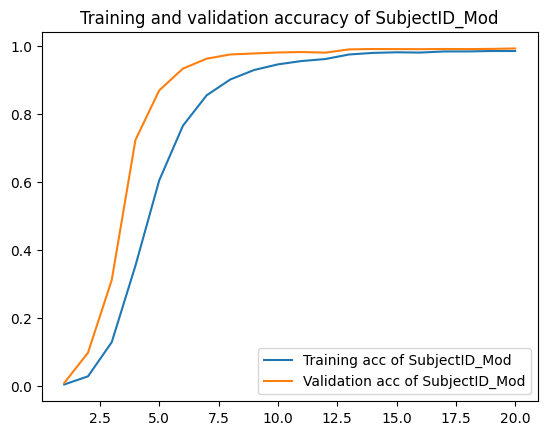

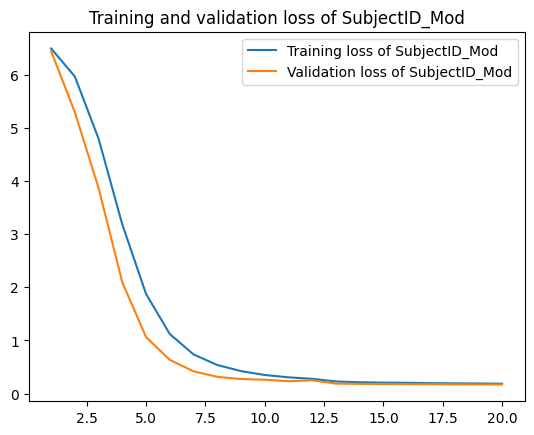

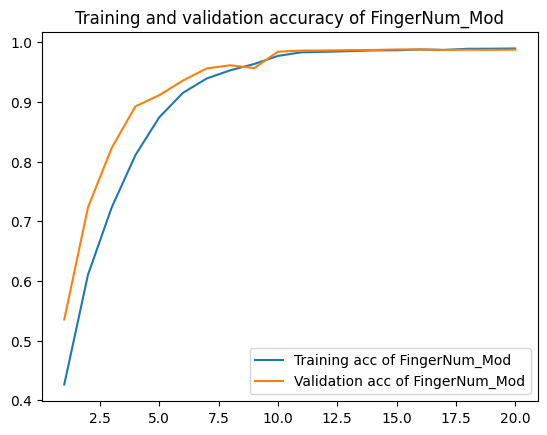

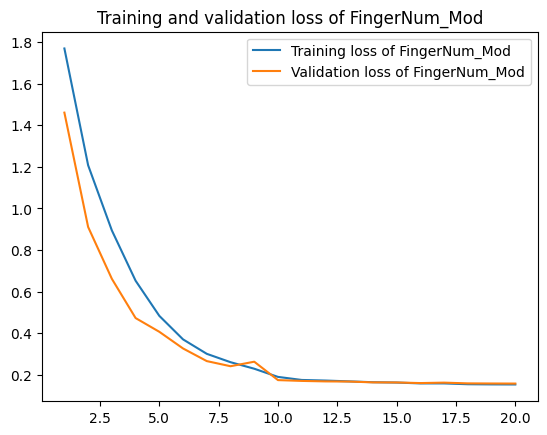

In [23]:
acc = [0] * nets
val_acc = [0] * nets
loss = [0] * nets
val_loss = [0] * nets

for i in range(nets):
    acc[i] = history[i].history['accuracy']
    val_acc[i] = history[i].history['val_accuracy']
    loss[i] = history[i].history['loss']
    val_loss[i] = history[i].history['val_loss']

    epochs = range(1, len(acc[i]) + 1)
    plt.figure()
    plt.plot(epochs, acc[i], label='Training acc of '+model_name[i])
    plt.plot(epochs, val_acc[i], label='Validation acc of '+model_name[i])
    plt.title('Training and validation accuracy of '+model_name[i])
    plt.legend()

    plt.figure()
    plt.plot(epochs, loss[i], label='Training loss of '+model_name[i])
    plt.plot(epochs, val_loss[i], label='Validation loss of '+model_name[i])
    plt.title('Training and validation loss of '+model_name[i])
    plt.legend()

Model evaluation

In [24]:
testing_acc_Id = model[0].evaluate([X_test], [y_SubjectID_test], verbose=0)
print("Id recognition accuracy: ",testing_acc_Id[1]*100, "%")
testing_acc_finger = model[1].evaluate([X_test], [y_fingerNum_test], verbose=0)
print("Finger recognition accuracy: ",testing_acc_finger[1]*100, "%")

Id recognition accuracy:  99.75000023841858 %
Finger recognition accuracy:  99.90000128746033 %


Confusion matrix visualization function

In [25]:
def plot_confusion_matrix(conmat, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    plt.imshow(conmat, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes)
    plt.yticks(tick_marks, classes)

    if normalize:
        conmat = conmat.astype('float') / conmat.sum(axis=1)[:, np.newaxis]

    thresh = conmat.max() / 2.
    for i, j in itertools.product(range(conmat.shape[0]), range(conmat.shape[1])):
        plt.text(j, i, conmat[i, j],
                 horizontalalignment="center",
                 color="white" if conmat[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('Real label')
    plt.xlabel('Predicted label')

Generate and plot confusion matrix

188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


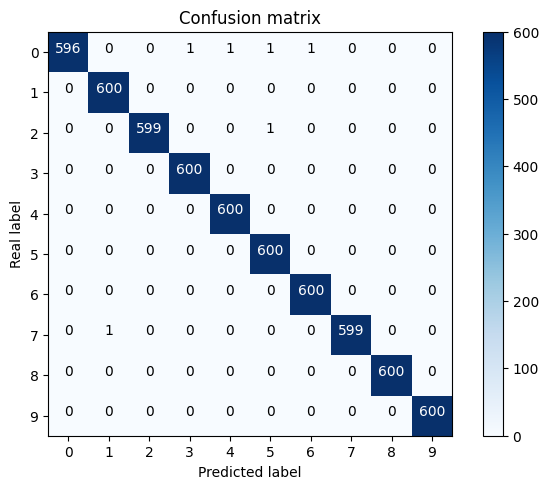

In [26]:
y_fingerNum_pred = model[1].predict(X_test)
y_fingerNum_pred_classes = np.argmax(y_fingerNum_pred, axis=1)
y_fingerNum_real = np.argmax(y_fingerNum_test, axis=1)
confusion_mtx = confusion_matrix(y_fingerNum_real, y_fingerNum_pred_classes)
plot_confusion_matrix(confusion_mtx, classes=range(10))

Random prediction test

188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
Information confirm! Fingerprint matches: person Id 323 left index


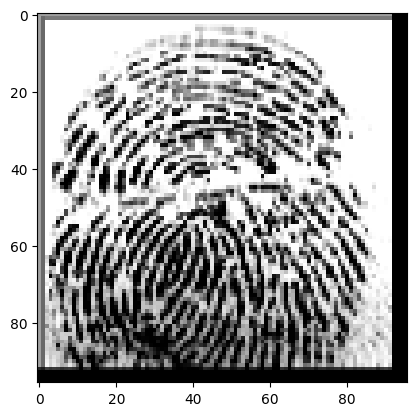

In [27]:
def show_fingername(fingernum):
    if fingernum>=5:
        fingername = "right "
        fingernum -= 5
    else: fingername = "left "
    if fingernum==0:
        fingername += "little"
    elif fingernum==1:
        fingername += "ring"
    elif fingernum==2:
        fingername += "middle"
    elif fingernum==3:
        fingername += "index"
    else: fingername += "thumb"
    return fingername

rand_fp_num = random.randint(0, X_test.shape[0]-1)
plt.imshow(X_test[rand_fp_num].reshape((96, 96)), cmap='gray')
y_SubjectID_pred = model[0].predict(X_test)
Id_pred = np.argmax(y_SubjectID_pred[rand_fp_num])
Id_real = np.argmax(y_SubjectID_test[rand_fp_num])
fingerNum_pred = np.argmax(y_fingerNum_pred[rand_fp_num])
fingerNum_real = np.argmax(y_fingerNum_test[rand_fp_num])

if Id_pred==Id_real and fingerNum_pred==fingerNum_real:
    print("Information confirm! Fingerprint matches: person Id",Id_pred, show_fingername(fingerNum_pred))
else:
    print("Oops! Prediction is wrong!")